# Applied Data Intelligence
## Project Deliverables 3 – Stock Market Prediction
**Team Members:** Gowtham Prakash Medikondla, Architha Keshavaraju, Vivek Reddy Yasa 
**Dataset:** Stock Market Dataset (183,999 training samples, 30 features, binary response)  
**Objective:** Predict whether a stock should be purchased (1 = Buy, 0 = Do Not Buy)

---
## Step 1: Install & Import Libraries

In [10]:
import xgboost
import lightgbm
from imblearn import *

In [11]:
# Data manipulation and numerical libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Using Scikit-learn for preprocessing, models, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, precision_score, recall_score, f1_score
)

# Ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 2: Load Data

In [12]:
# Loading the combined training dataset
train_df = pd.read_csv('stock_market_train.csv')
print(f'Training data shape: {train_df.shape}')

Training data shape: (183999, 31)


In [13]:
# Loading original test set and new test set 
test_old_df = pd.read_csv('stock_market_test_features.csv')   # Original test set
test_new_df = pd.read_csv('stock_market_newtest.csv')          # New test set 
print(f'Old test data shape: {test_old_df.shape}')
print(f'New test data shape: {test_new_df.shape}')

Old test data shape: (46000, 30)
New test data shape: (46000, 30)


---
## Step 3: Project Description & Initial Exploration

In [14]:
# Displaying first few rows to understand data structure
train_df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Response
0,-1.148434,1.117403,1.392239,1.016618,0.300527,0.324227,0.195595,0.577848,-0.199389,-0.732150,...,-1.375906,-0.210895,-0.700718,0.535527,-0.745558,0.241494,0.035374,8.85,89738.0,0
1,1.202869,-0.480561,0.771509,-0.897333,-1.031278,-0.284446,-0.708919,0.134662,1.625075,-0.905111,...,0.716104,-0.195189,0.052651,0.632512,-0.529605,0.087937,0.021587,14.00,64729.0,0
2,-2.514132,-3.298636,1.442359,-1.598434,0.603521,-1.854154,-0.694881,0.065849,-2.605633,0.791450,...,-0.085763,0.674857,0.479313,0.811347,-0.172587,-0.143169,0.105041,261.00,40193.0,0
3,-0.543319,-0.084795,0.456642,-2.542358,1.156229,1.558163,-0.107803,0.424925,-0.686666,-0.551871,...,1.060019,-0.332281,-1.075855,-0.224583,-0.138144,-0.117548,-0.073443,24.00,145169.0,0
4,-0.847302,1.492225,1.913864,2.249975,-0.058666,-0.268322,0.772814,-0.009808,-0.799108,-0.251945,...,-0.833569,0.031846,0.561385,-0.322551,-0.362057,-0.128947,0.152181,37.92,46765.0,0


In [15]:
# Summary of the statistics
train_df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X22,X23,X24,X25,X26,X27,X28,X29,X30,Response
count,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,...,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000,183999.000000
mean,-0.019091,-0.041272,0.041302,0.005902,-0.029594,0.011702,-0.006941,0.002652,-0.056753,0.014249,...,0.001306,-0.002945,0.000231,0.012202,-0.000905,-0.001836,0.000240,92.515852,91387.868423,0.001989
std,1.980809,1.688210,1.500350,1.414386,1.386901,1.326986,1.235733,1.189660,1.077804,1.078861,...,0.721294,0.632976,0.607618,0.520213,0.481514,0.404736,0.341786,256.874719,38968.666147,0.044556
min,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.320155,-24.588262,...,-10.933144,-36.666000,-2.836627,-8.696627,-2.604551,-22.565679,-11.710896,0.000000,406.000000,0.000000
25%,-0.932305,-0.636512,-0.804934,-0.850262,-0.727467,-0.756535,-0.561532,-0.204185,-0.685071,-0.511375,...,-0.530102,-0.164279,-0.352494,-0.302234,-0.328983,-0.070639,-0.052132,5.990000,57085.000000,0.000000
50%,0.019128,0.045461,0.228565,-0.003701,-0.084525,-0.257739,0.029710,0.028839,-0.093583,-0.078029,...,0.012280,-0.015197,0.044097,0.037809,-0.060674,0.002144,0.013202,24.000000,81047.000000,0.000000
75%,1.291938,0.773317,1.050973,0.767361,0.585858,0.415998,0.556503,0.334631,0.535176,0.483257,...,0.522273,0.141496,0.436333,0.360417,0.243716,0.088921,0.078139,80.955000,129678.500000,0.000000
max,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,23.745136,...,10.503090,22.528412,4.022866,7.519589,3.220178,12.152401,33.847808,19656.530000,154674.000000,1.000000


In [16]:
print('Data types:')
print(train_df.dtypes)
print(f'\nTotal samples : {len(train_df):,}')
print(f'Total features: {train_df.shape[1] - 1}')

Data types:
X1          float64
X2          float64
X3          float64
X4          float64
X5          float64
X6          float64
X7          float64
X8          float64
X9          float64
X10         float64
X11         float64
X12         float64
X13         float64
X14         float64
X15         float64
X16         float64
X17         float64
X18         float64
X19         float64
X20         float64
X21         float64
X22         float64
X23         float64
X24         float64
X25         float64
X26         float64
X27         float64
X28         float64
X29         float64
X30         float64
Response      int64
dtype: object

Total samples : 183,999
Total features: 30


---
## Step 4: Data Visualization
### 4.1 Distribution of Response Variable

Response distribution:
Response
0    183633
1       366
Name: count, dtype: int64

Class imbalance ratio: 501.7:1


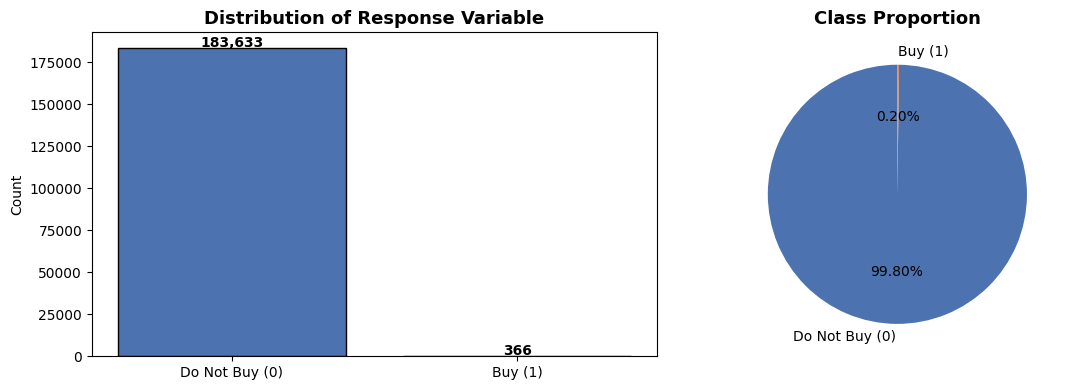

In [17]:
response_counts = train_df['Response'].value_counts()
print('Response distribution:')
print(response_counts)
print(f'\nClass imbalance ratio: {response_counts[0]/response_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Do Not Buy (0)', 'Buy (1)'], response_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Distribution of Response Variable', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(response_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(response_counts.values, labels=['Do Not Buy (0)', 'Buy (1)'],
            autopct='%1.2f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('response_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Feature Histograms

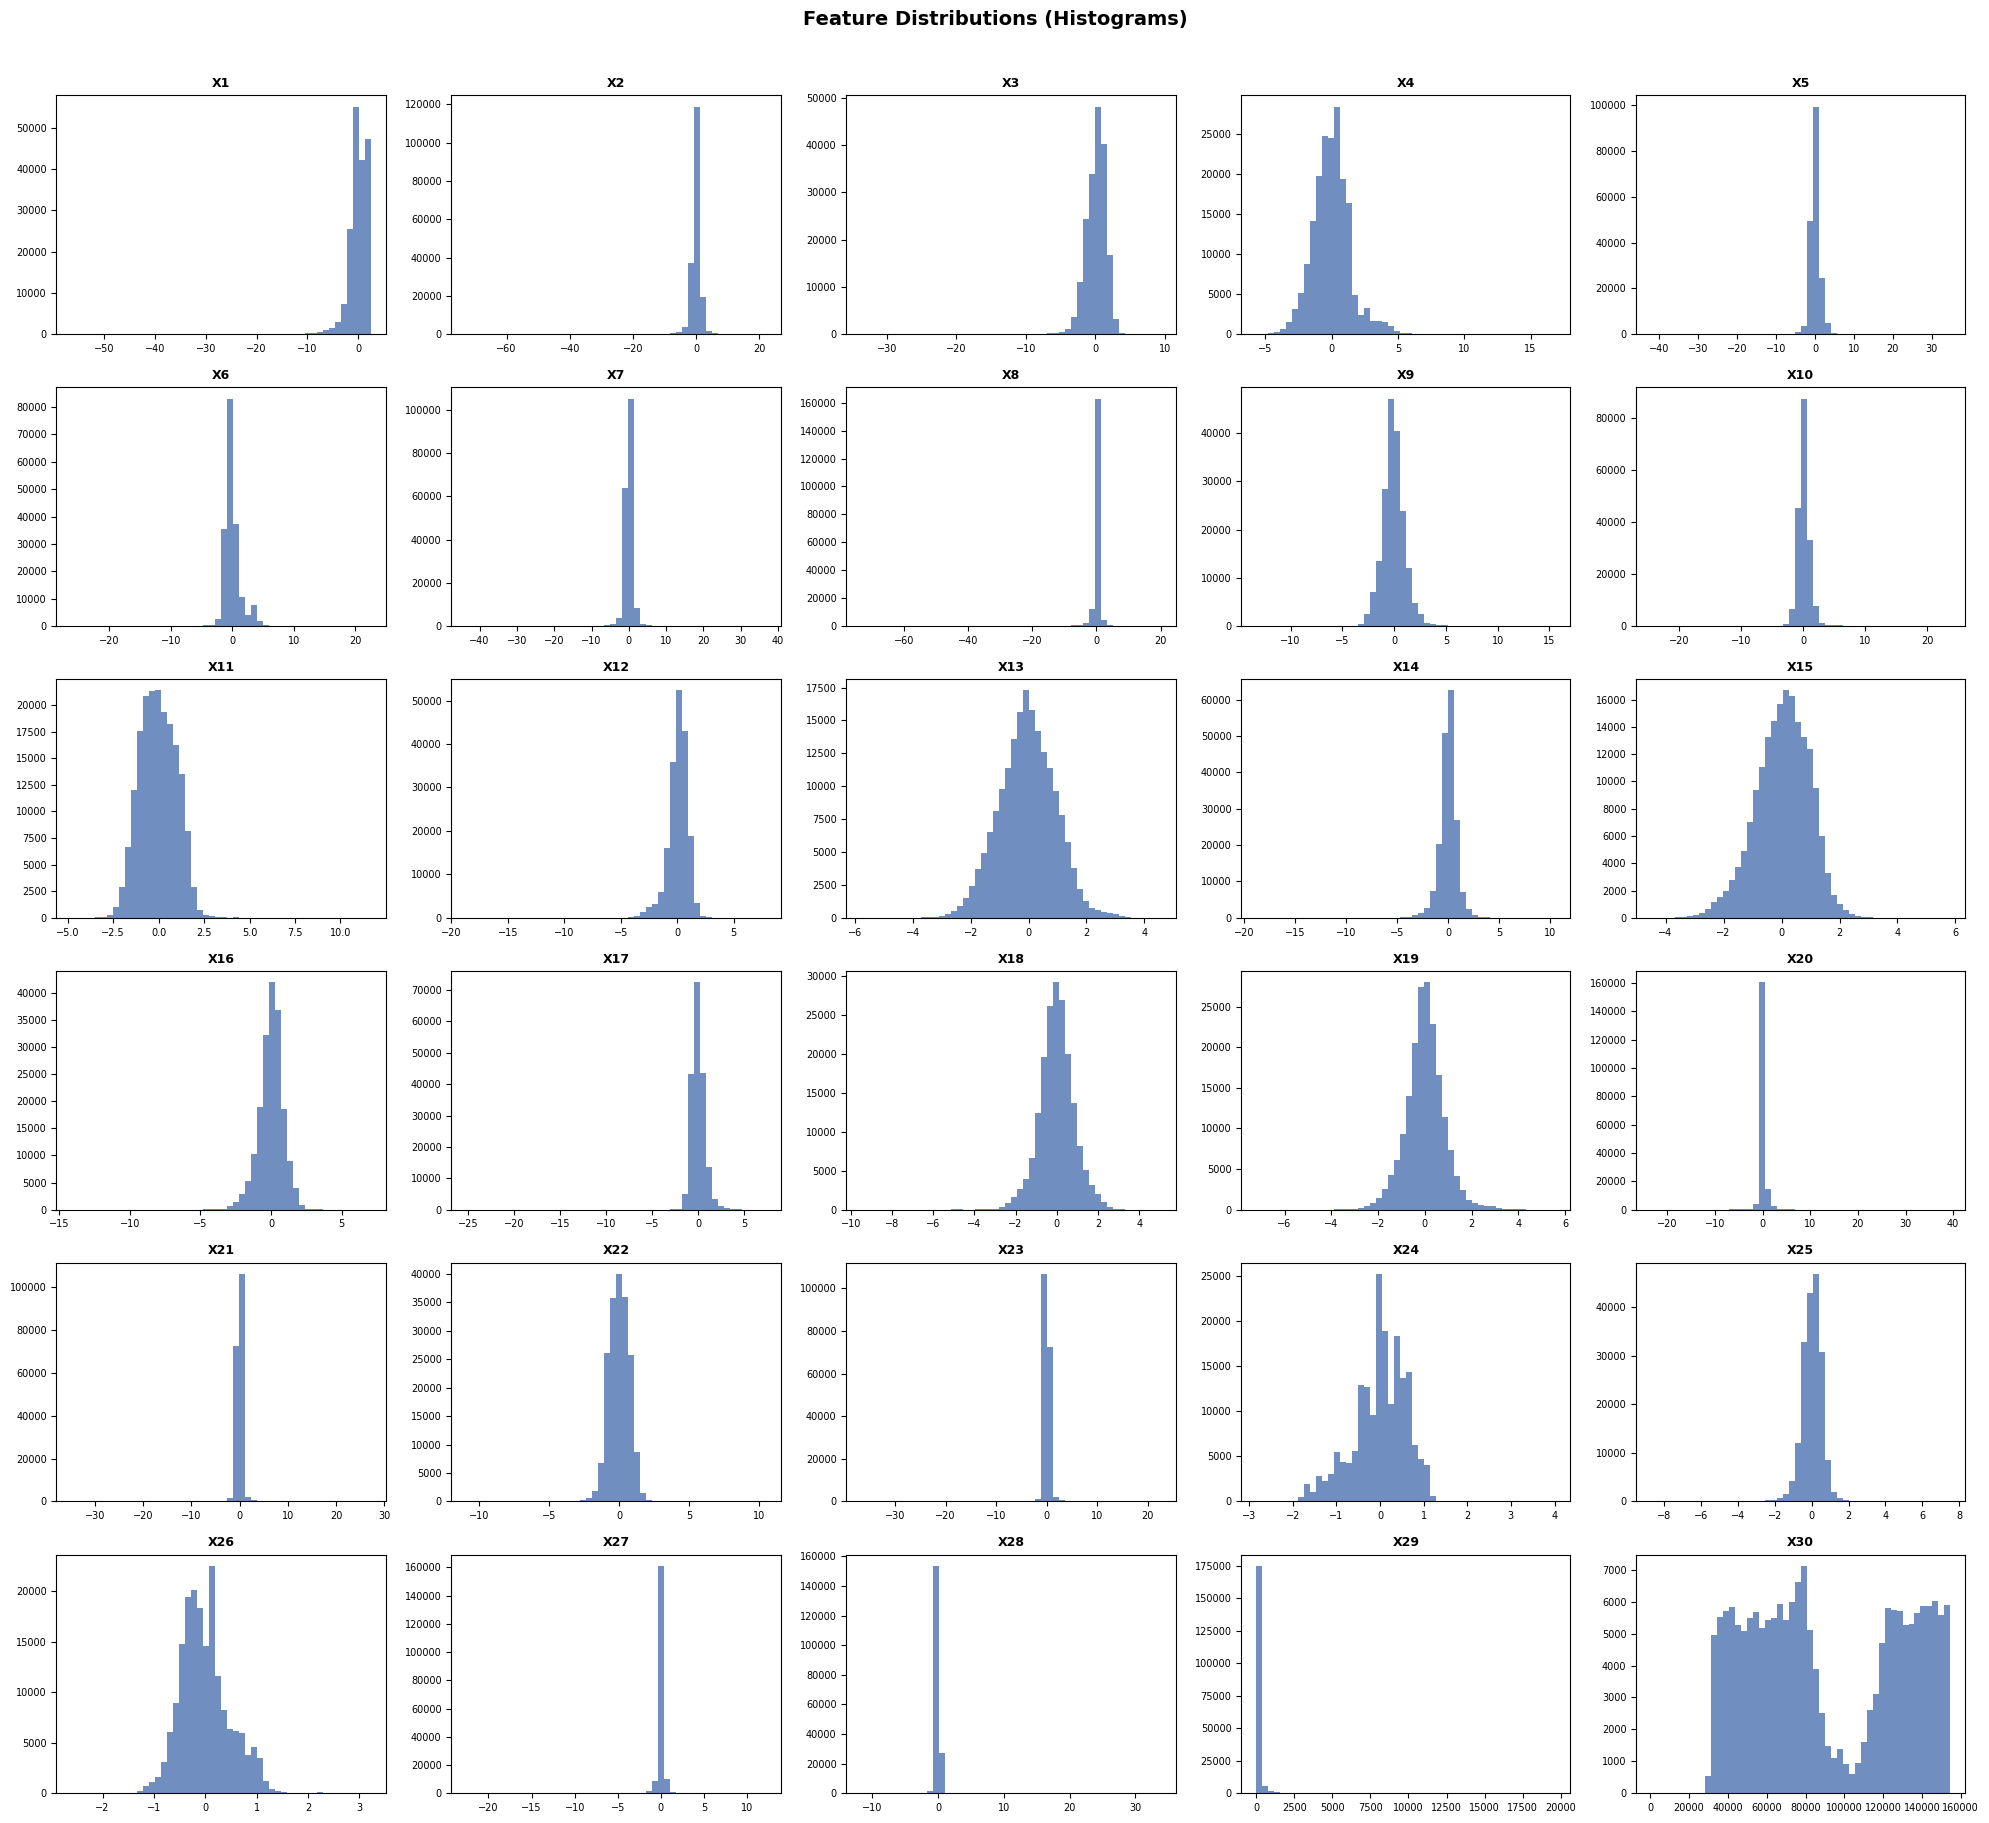

In [18]:
feature_cols = [col for col in train_df.columns if col != 'Response']

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=50, color='#4C72B0', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions (Histograms)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Correlation Heatmap

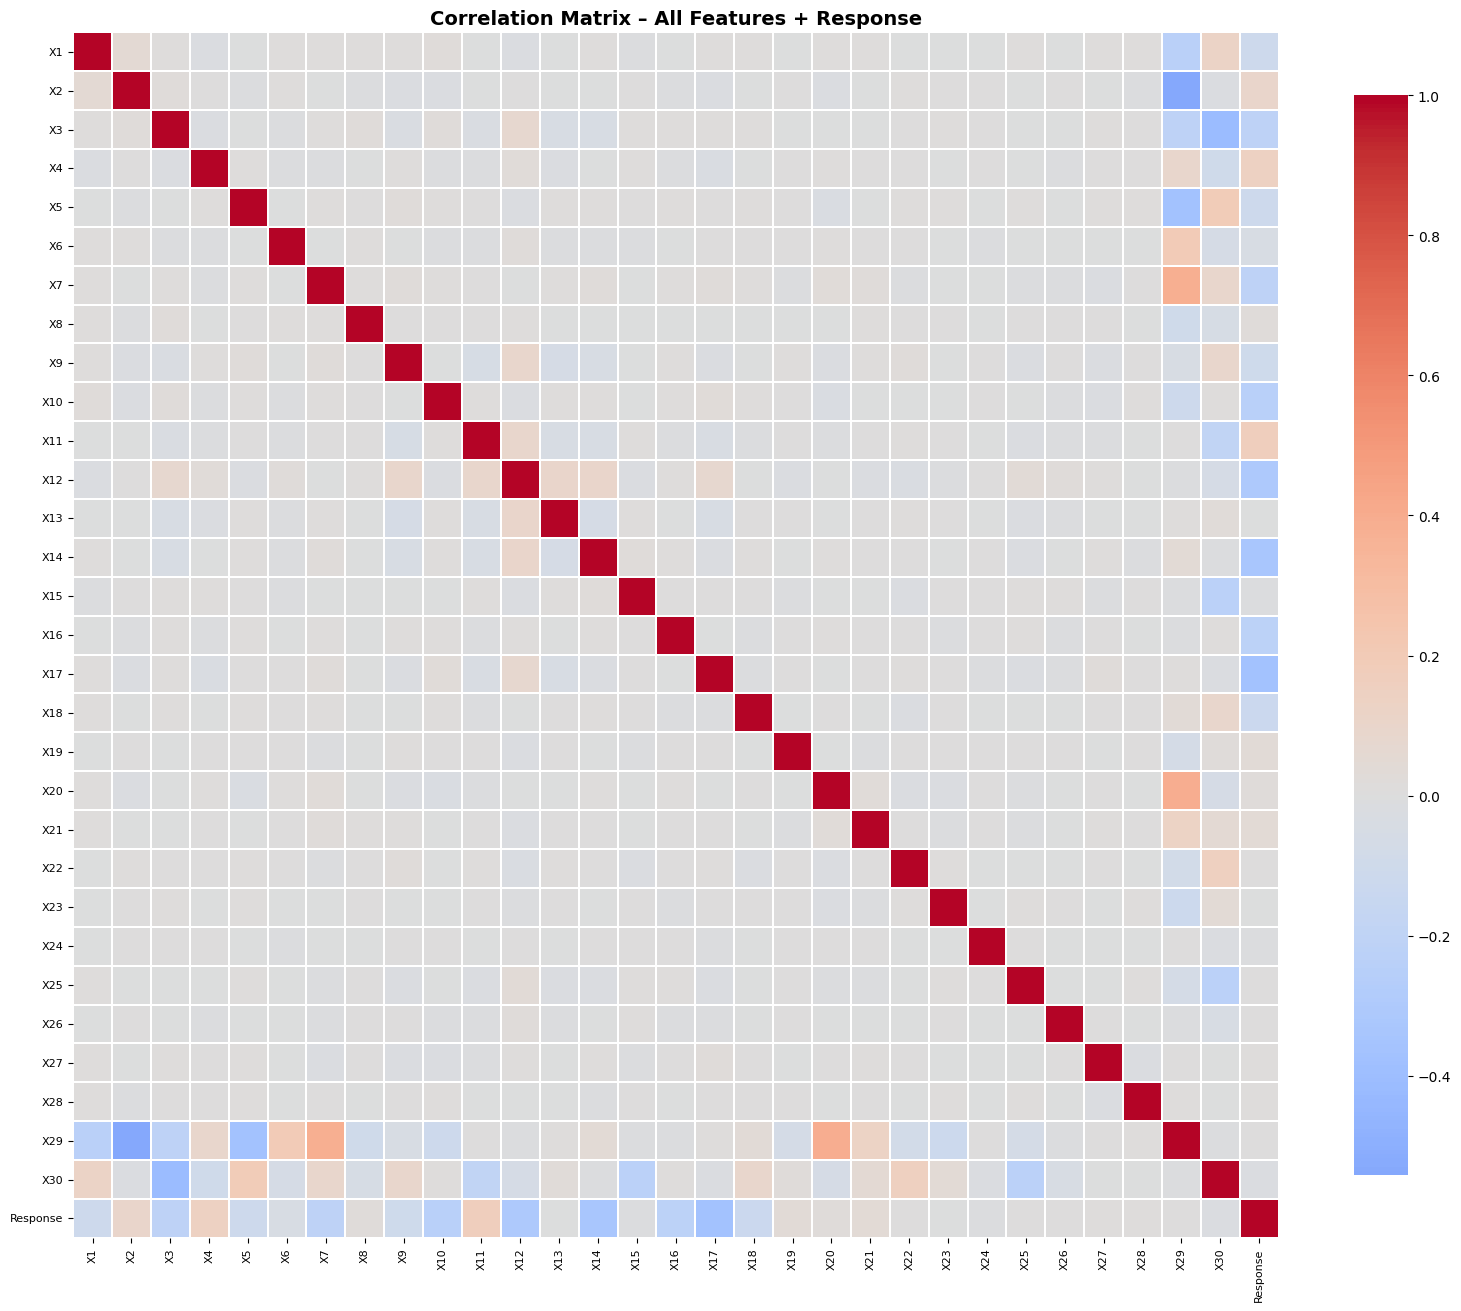

Top 10 features most correlated with Response:
X17    0.372923
X14    0.332318
X12    0.309190
X10    0.245438
X16    0.219399
X3     0.215770
X7     0.213331
X11    0.173836
X4     0.143595
X18    0.126338
Name: Response, dtype: float64


In [19]:
corr_matrix = train_df.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3,
            annot=False, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix – All Features + Response', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

response_corr = corr_matrix['Response'].drop('Response').abs().sort_values(ascending=False)
print('Top 10 features most correlated with Response:')
print(response_corr.head(10))

### 4.4 Box Plots – Top Features by Response Class

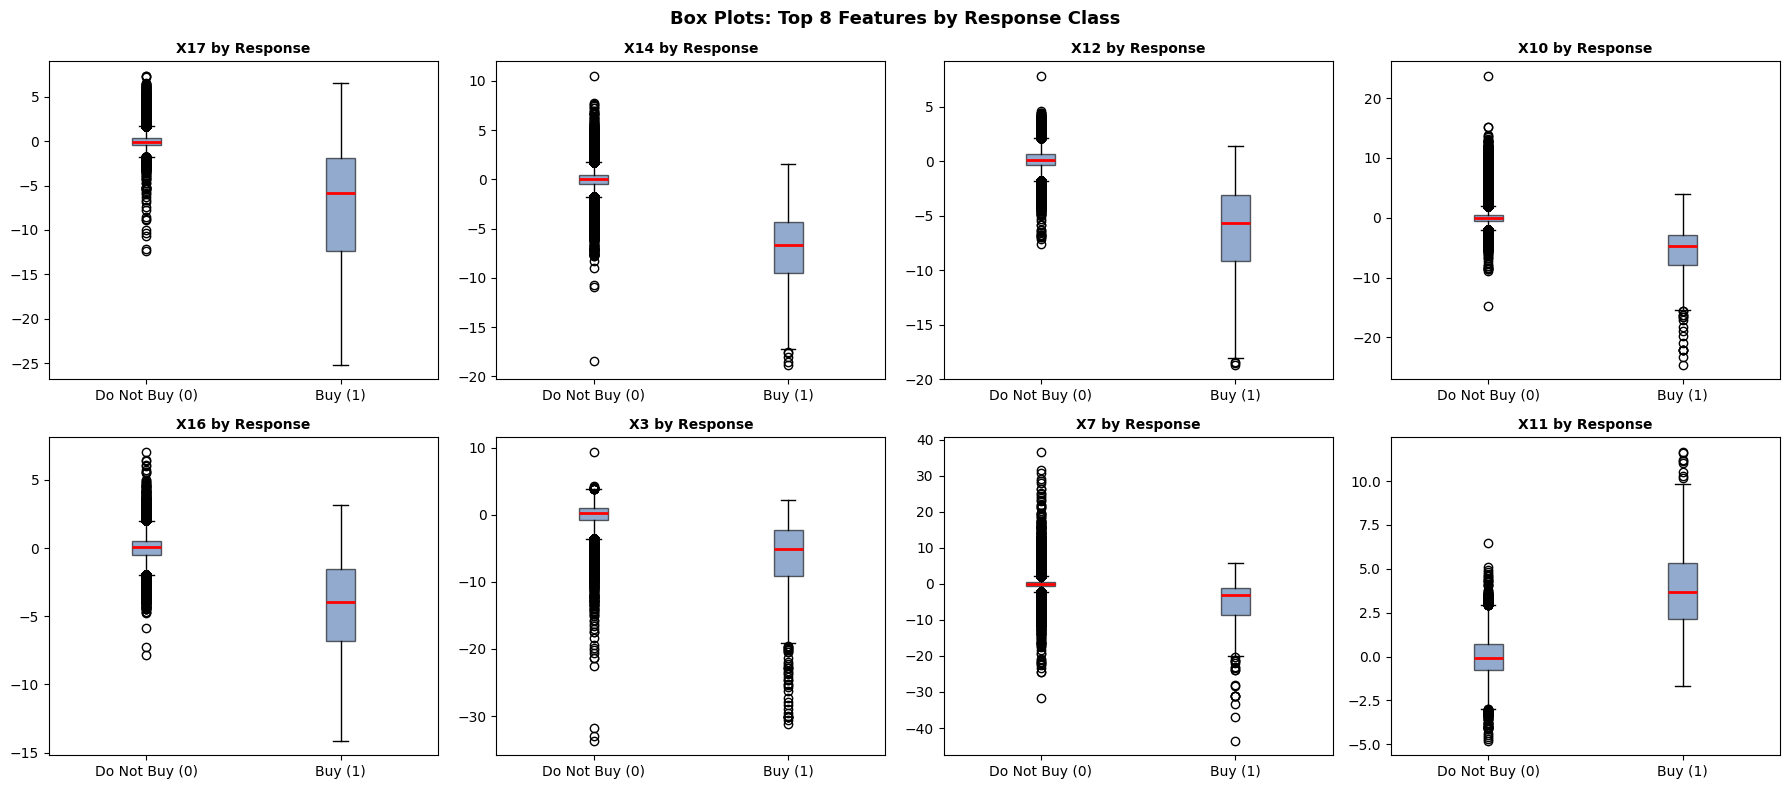

In [20]:
top_features = response_corr.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    data_0 = train_df[train_df['Response'] == 0][col]
    data_1 = train_df[train_df['Response'] == 1][col]
    axes[i].boxplot([data_0, data_1], labels=['Do Not Buy (0)', 'Buy (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Response', fontsize=10, fontweight='bold')
plt.suptitle('Box Plots: Top 8 Features by Response Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Data Pre-Processing
### 5.1 Missing Value Check

In [21]:
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

No missing values found.


### 5.2 Train/Validation Split

In [22]:
X = train_df.drop(columns=['Response'])
y = train_df['Response']

# 80/20 split preserves class ratio in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Training  : {X_train.shape[0]:,} samples')
print(f'Validation: {X_val.shape[0]:,} samples')
print(f'\nClass distribution (training):')
print(y_train.value_counts())

Training  : 147,199 samples
Validation: 36,800 samples

Class distribution (training):
Response
0    146906
1       293
Name: count, dtype: int64


### 5.3 Feature Scaling
X1-X28 are already normalized. X29 and X30 have raw scales. We apply StandardScaler to all features for consistency. Scaler is fit only on training data to prevent data leakage.

In [23]:
scaler = StandardScaler()
X_train_scaled    = scaler.fit_transform(X_train)
X_val_scaled      = scaler.transform(X_val)
X_test_old_scaled = scaler.transform(test_old_df)  # Original test set
X_test_new_scaled = scaler.transform(test_new_df)  # New test set
print('Feature scaling complete for all datasets.')

Feature scaling complete for all datasets.


### 5.4 SMOTE Oversampling
The 502:1 class imbalance would cause any model to ignore the minority class. SMOTE synthesizes new minority class samples until Buy reaches 10% of the majority class, applied only on training data.

In [24]:
smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE resampling:')
unique, counts = np.unique(y_train_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  Class {int(cls)}: {cnt:,} samples')

# Computing scale_pos_weight for XGBoost
neg_count = (y_train_resampled == 0).sum()
pos_count = (y_train_resampled == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'\nscale_pos_weight for XGBoost: {scale_pos_weight:.2f}')

After SMOTE resampling:
  Class 0: 146,906 samples
  Class 1: 14,690 samples

scale_pos_weight for XGBoost: 10.00


---
## Step 6: Helper Function – Threshold Optimization & Metrics
A reusable function to find the optimal classification threshold by maximizing F1-score for the Buy class, and compute all required evaluation metrics.

In [25]:
def optimize_threshold_and_evaluate(model, X_val, y_val, model_name):
    """Find optimal threshold by F1 and return all evaluation metrics."""
    prob = model.predict_proba(X_val)[:, 1]

    # Sweep thresholds 0.01 to 0.99
    thresholds = np.arange(0.01, 0.99, 0.01)
    f1_scores  = [f1_score(y_val, (prob >= t).astype(int), zero_division=0)
                  for t in thresholds]

    best_threshold = thresholds[np.argmax(f1_scores)]
    pred_optimal   = (prob >= best_threshold).astype(int)

    # Compute all metrics
    cm             = confusion_matrix(y_val, pred_optimal)
    tn, fp, fn, tp = cm.ravel()
    sensitivity    = tp / (tp + fn) if (tp + fn) > 0 else 0   # Recall
    specificity    = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision      = precision_score(y_val, pred_optimal, zero_division=0)
    f1             = f1_score(y_val, pred_optimal, zero_division=0)
    auc            = roc_auc_score(y_val, prob)
    accuracy       = (tp + tn) / len(y_val)

    print(f'\n{model_name} - Optimal Threshold: {best_threshold:.2f}')
    print(f'  AUC={auc:.4f}  Acc={accuracy:.4f}  Sens={sensitivity:.4f}  '
          f'Spec={specificity:.4f}  Prec={precision:.4f}  F1={f1:.4f}')

    return {
        'prob': prob, 'pred': pred_optimal, 'threshold': best_threshold,
        'AUC-ROC': auc, 'Accuracy': accuracy, 'Sensitivity': sensitivity,
        'Specificity': specificity, 'Precision': precision, 'F1-Score': f1
    }

print('Helper function defined.')

Helper function defined.


---

## PROJECT DELIVERABLE 1 - LOGISTIC REGRESSION

## Step 7: Model 1 – Logistic Regression
Logistic Regression is chosen as the baseline because it is computationally efficient, interpretable, and well-suited for large binary classification datasets. class_weight='balanced' provides an additional correction for the class imbalance.

In [26]:
# Training Logistic Regression on SMOTE-resampled training data
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_model.fit(X_train_resampled, y_train_resampled)
lr_results = optimize_threshold_and_evaluate(lr_model, X_val_scaled, y_val, 'Logistic Regression')


Logistic Regression - Optimal Threshold: 0.98
  AUC=0.9936  Acc=0.9979  Sens=0.9315  Spec=0.9980  Prec=0.4823  F1=0.6355


In [27]:
# Detailed classification report
print('Classification Report:')
print(classification_report(y_val, lr_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9999    0.9980    0.9989     36727
       Buy (1)     0.4823    0.9315    0.6355        73

      accuracy                         0.9979     36800
     macro avg     0.7411    0.9648    0.8172     36800
  weighted avg     0.9988    0.9979    0.9982     36800



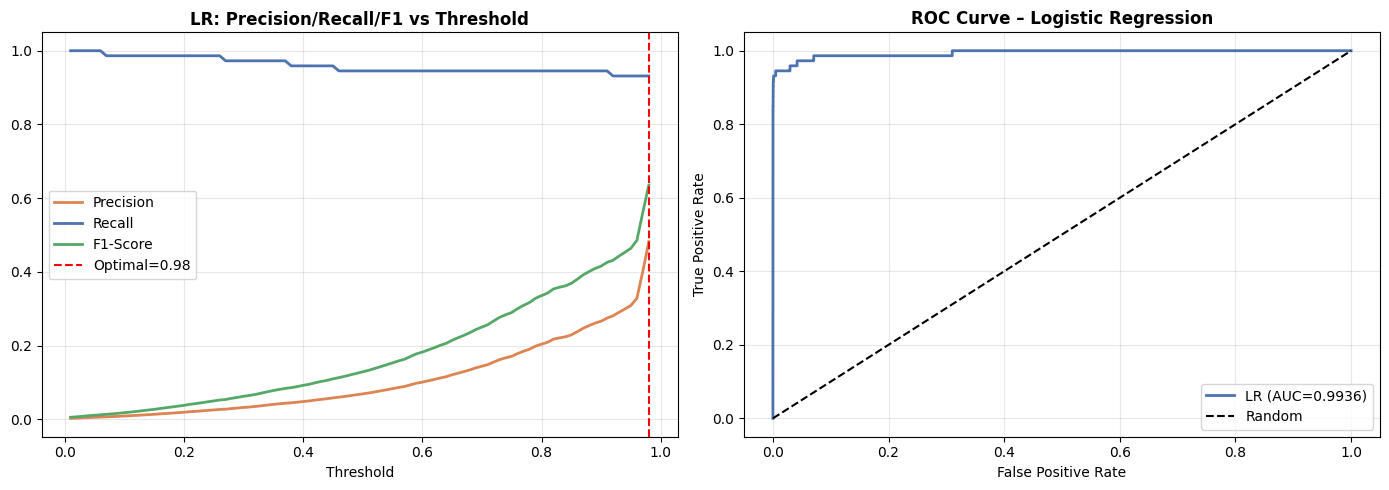

In [28]:
# Logistic Regression - Threshold optimization plot
thresholds = np.arange(0.01, 0.99, 0.01)
lr_prob = lr_results['prob']
lr_precs = [precision_score(y_val, (lr_prob>=t).astype(int), zero_division=0) for t in thresholds]
lr_recs  = [recall_score(y_val, (lr_prob>=t).astype(int), zero_division=0) for t in thresholds]
lr_f1s   = [f1_score(y_val, (lr_prob>=t).astype(int), zero_division=0) for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, lr_precs, label='Precision', color='#DD8452', lw=2)
axes[0].plot(thresholds, lr_recs,  label='Recall',    color='#4C72B0', lw=2)
axes[0].plot(thresholds, lr_f1s,   label='F1-Score',  color='#55A868', lw=2)
axes[0].axvline(lr_results['threshold'], color='red', linestyle='--',
                label=f'Optimal={lr_results["threshold"]:.2f}')
axes[0].set_title('LR: Precision/Recall/F1 vs Threshold', fontweight='bold')
axes[0].set_xlabel('Threshold'); axes[0].legend(); axes[0].grid(alpha=0.3)

lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_prob)
axes[1].plot(lr_fpr, lr_tpr, color='#4C72B0', lw=2,
             label=f'LR (AUC={lr_results["AUC-ROC"]:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve – Logistic Regression', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_threshold_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---

## PROJECT DELIVERABLE 2 - RANDOM FOREST & XGBOOST

## Step 8: Model 2 - Random Forest
Random Forest is an ensemble of decision trees trained on random data and feature subsets. It handles non-linear relationships, is robust to outliers, and provides reliable feature importance. class_weight='balanced' adjusts for the 502:1 imbalance at the tree level.

In [29]:
# Train Random Forest - 300 trees, balanced class weights, parallel training
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=15,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_results = optimize_threshold_and_evaluate(rf_model, X_val_scaled, y_val, 'Random Forest')


Random Forest - Optimal Threshold: 0.72
  AUC=0.9957  Acc=0.9996  Sens=0.8767  Spec=0.9998  Prec=0.9014  F1=0.8889


In [30]:
print('Classification Report:')
print(classification_report(y_val, rf_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9998    0.9998    0.9998     36727
       Buy (1)     0.9014    0.8767    0.8889        73

      accuracy                         0.9996     36800
     macro avg     0.9506    0.9383    0.9443     36800
  weighted avg     0.9996    0.9996    0.9996     36800



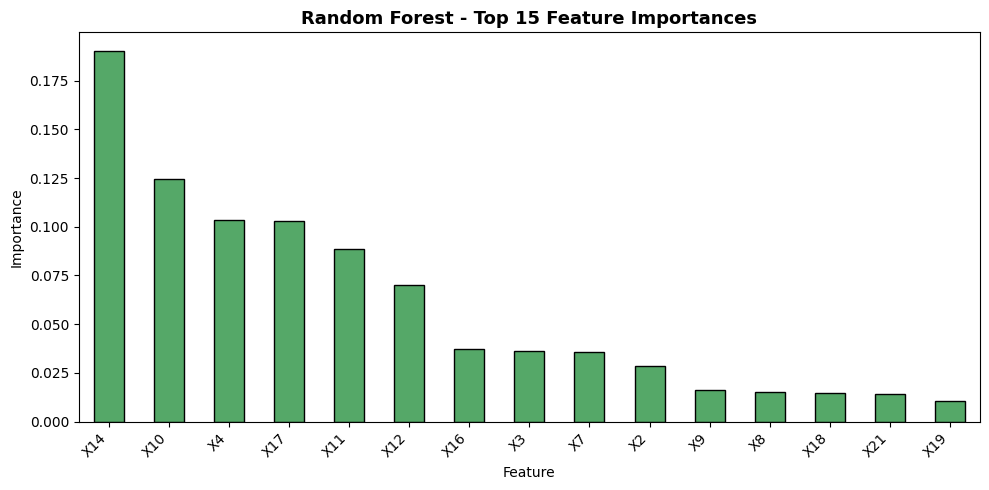

In [31]:
# Random Forest Feature Importance
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
rf_importance.head(15).plot(kind='bar', color='#55A868', edgecolor='black')
plt.title('Random Forest - Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Feature'); plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Model 3 – XGBoost Untuned
XGBoost uses sequential boosting where each tree corrects errors of the previous one. `scale_pos_weight` is computed on SMOTE-resampled data (~10:1 ratio), providing additional imbalance correction on top of SMOTE.

In [32]:
# Train XGBoost untuned
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train_resampled, y_train_resampled)
xgb_results = optimize_threshold_and_evaluate(xgb_model, X_val_scaled, y_val, 'XGBoost (Untuned)')


XGBoost (Untuned) - Optimal Threshold: 0.93
  AUC=0.9932  Acc=0.9996  Sens=0.8904  Spec=0.9999  Prec=0.9286  F1=0.9091


In [33]:
print('Classification Report:')
print(classification_report(y_val, xgb_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9998    0.9999    0.9998     36727
       Buy (1)     0.9286    0.8904    0.9091        73

      accuracy                         0.9996     36800
     macro avg     0.9642    0.9451    0.9545     36800
  weighted avg     0.9996    0.9996    0.9996     36800



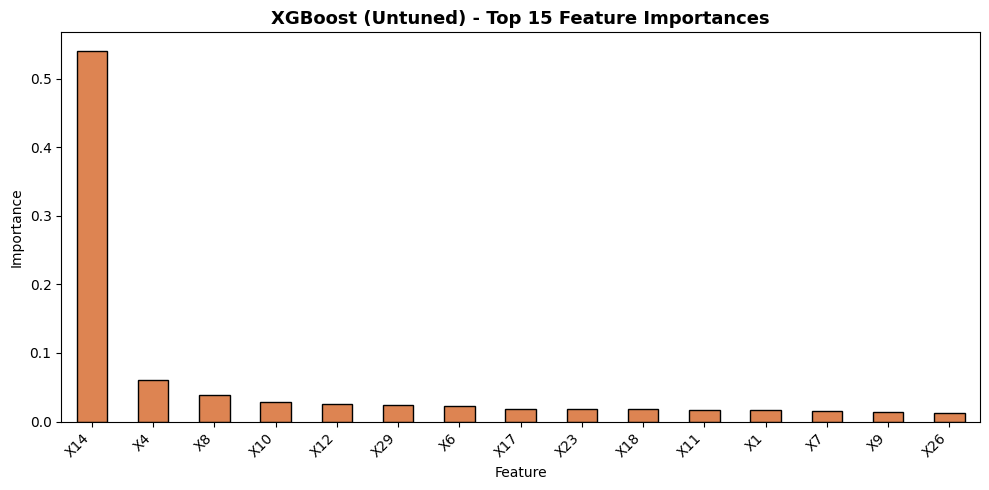

In [34]:
# XGBoost Feature Importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
xgb_importance.head(15).plot(kind='bar', color='#DD8452', edgecolor='black')
plt.title('XGBoost (Untuned) - Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Feature'); plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 
## PROJECT DELIVERABLE 3 - NEW MODELS & TUNING
## 
## Step 10: XGBoost Hyperparameter Tuning
Following the professor's recommendation, we perform a manual sweep over max_depth, learning_rate, and subsample to recover the small recall gap and improve overall F1-score.

In [35]:
# Manual hyperparameter sweep for XGBoost
# Parameters to tune:
# max_depth    : controls tree complexity - deeper = more complex patterns
# learning_rate: step size at each iteration - smaller = more careful learning
# subsample    : fraction of training samples used per tree - reduces overfitting

param_grid = [
    (md, lr, ss)
    for md in [4, 6, 8]
    for lr in [0.05, 0.1]
    for ss in [0.7, 0.8, 0.9]
]

tuning_results = []
print(f'Testing {len(param_grid)} parameter combinations...')
print(f'{"max_depth":<12} {"lr":<8} {"subsample":<12} {"F1":>8} {"Precision":>10} {"Recall":>8} {"AUC":>8}')
print('-' * 65)

for md, lr, ss in param_grid:
    m = XGBClassifier(
        n_estimators=300, max_depth=md, learning_rate=lr, subsample=ss,
        scale_pos_weight=scale_pos_weight, eval_metric='auc',
        use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
    )
    m.fit(X_train_resampled, y_train_resampled)
    prob = m.predict_proba(X_val_scaled)[:, 1]
    ths  = np.arange(0.01, 0.99, 0.01)
    f1s  = [f1_score(y_val, (prob>=t).astype(int), zero_division=0) for t in ths]
    bt   = ths[np.argmax(f1s)]
    pred = (prob >= bt).astype(int)
    f1   = f1_score(y_val, pred, zero_division=0)
    prec = precision_score(y_val, pred, zero_division=0)
    rec  = recall_score(y_val, pred, zero_division=0)
    auc  = roc_auc_score(y_val, prob)
    tuning_results.append((md, lr, ss, bt, f1, prec, rec, auc, m))
    print(f'{md:<12} {lr:<8} {ss:<12} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f} {auc:>8.4f}')

# Select best combination by F1-score
tuning_results.sort(key=lambda x: -x[4])
best_md, best_lr, best_ss, best_bt, best_f1, best_prec, best_rec, best_auc, xgb_tuned_model = tuning_results[0]

print(f'\nBest parameters: max_depth={best_md}, learning_rate={best_lr}, subsample={best_ss}')
print(f'Best F1={best_f1:.4f}  Precision={best_prec:.4f}  Recall={best_rec:.4f}  AUC={best_auc:.4f}')

Testing 18 parameter combinations...
max_depth    lr       subsample          F1  Precision   Recall      AUC
-----------------------------------------------------------------
4            0.05     0.7            0.9116     0.9054   0.9178   0.9904
4            0.05     0.8            0.8993     0.8816   0.9178   0.9902
4            0.05     0.9            0.9041     0.9041   0.9041   0.9886
4            0.1      0.7            0.9167     0.9296   0.9041   0.9915
4            0.1      0.8            0.9041     0.9041   0.9041   0.9920
4            0.1      0.9            0.9091     0.9286   0.8904   0.9879
6            0.05     0.7            0.9078     0.9412   0.8767   0.9935
6            0.05     0.8            0.9103     0.9167   0.9041   0.9920
6            0.05     0.9            0.9028     0.9155   0.8904   0.9914
6            0.1      0.7            0.9155     0.9420   0.8904   0.9944
6            0.1      0.8            0.9091     0.9286   0.8904   0.9944
6            0.1     

In [36]:
# Evaluating tuned XGBoost using the helper function
xgb_tuned_results = optimize_threshold_and_evaluate(
    xgb_tuned_model, X_val_scaled, y_val, 'XGBoost (Tuned)'
)
print('\nClassification Report:')
print(classification_report(y_val, xgb_tuned_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))


XGBoost (Tuned) - Optimal Threshold: 0.94
  AUC=0.9915  Acc=0.9997  Sens=0.9041  Spec=0.9999  Prec=0.9296  F1=0.9167

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9998    0.9999    0.9998     36727
       Buy (1)     0.9296    0.9041    0.9167        73

      accuracy                         0.9997     36800
     macro avg     0.9647    0.9520    0.9583     36800
  weighted avg     0.9997    0.9997    0.9997     36800



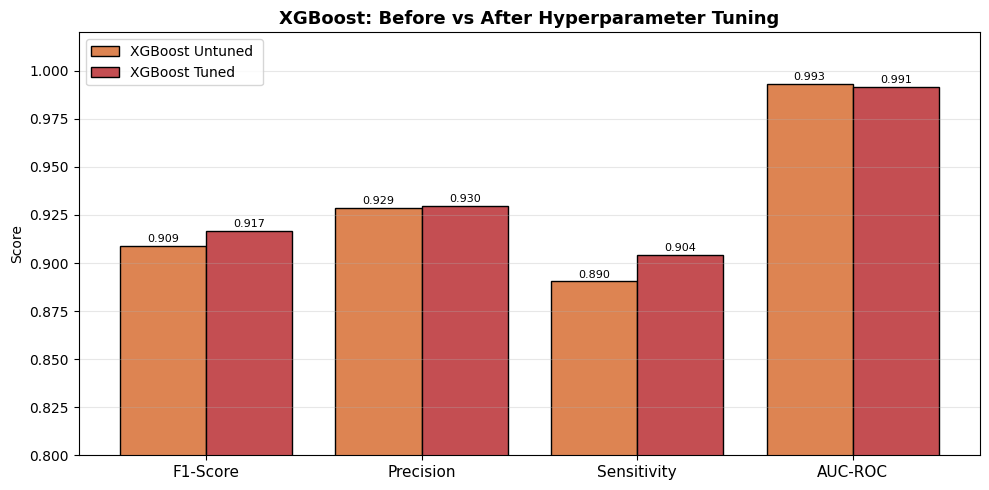

In [37]:
# Comparing tuning improvement as untuned vs tuned XGBoost
metrics = ['F1-Score', 'Precision', 'Sensitivity', 'AUC-ROC']
untuned_vals = [xgb_results['F1-Score'], xgb_results['Precision'],
                xgb_results['Sensitivity'], xgb_results['AUC-ROC']]
tuned_vals   = [xgb_tuned_results['F1-Score'], xgb_tuned_results['Precision'],
                xgb_tuned_results['Sensitivity'], xgb_tuned_results['AUC-ROC']]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, untuned_vals, 0.4, label='XGBoost Untuned ', color='#DD8452', edgecolor='black')
ax.bar(x + 0.2, tuned_vals,   0.4, label='XGBoost Tuned ',   color='#C44E52', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.8, 1.02); ax.set_ylabel('Score'); ax.legend(fontsize=10)
ax.set_title('XGBoost: Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (u, t) in enumerate(zip(untuned_vals, tuned_vals)):
    ax.text(i - 0.2, u + 0.002, f'{u:.3f}', ha='center', fontsize=8)
    ax.text(i + 0.2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('xgb_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Model 4 – LightGBM 
### Justification
LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework developed by Microsoft that was not covered in the course. It differs from XGBoost in key ways:
- Uses leaf-wise tree growth vs level-wise in XGBoost, making it faster and often more accurate
- is_unbalance=True is a native parameter designed specifically for imbalanced binary classification
- Significantly faster training speed on large datasets compared to XGBoost
- Uses histogram-based algorithms for memory efficiency
- Particularly effective when the number of data points is much larger than features (183k samples, 30 features)

In [38]:
# Train LightGBM on SMOTE-resampled data
# is_unbalance=True: native imbalance handling built into LightGBM
# verbose=-1: suppresses training output logs
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train_resampled, y_train_resampled)
lgbm_results = optimize_threshold_and_evaluate(lgbm_model, X_val_scaled, y_val, 'LightGBM')


LightGBM - Optimal Threshold: 0.97
  AUC=0.9954  Acc=0.9996  Sens=0.8904  Spec=0.9999  Prec=0.9286  F1=0.9091


In [39]:
print('Classification Report:')
print(classification_report(y_val, lgbm_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9998    0.9999    0.9998     36727
       Buy (1)     0.9286    0.8904    0.9091        73

      accuracy                         0.9996     36800
     macro avg     0.9642    0.9451    0.9545     36800
  weighted avg     0.9996    0.9996    0.9996     36800



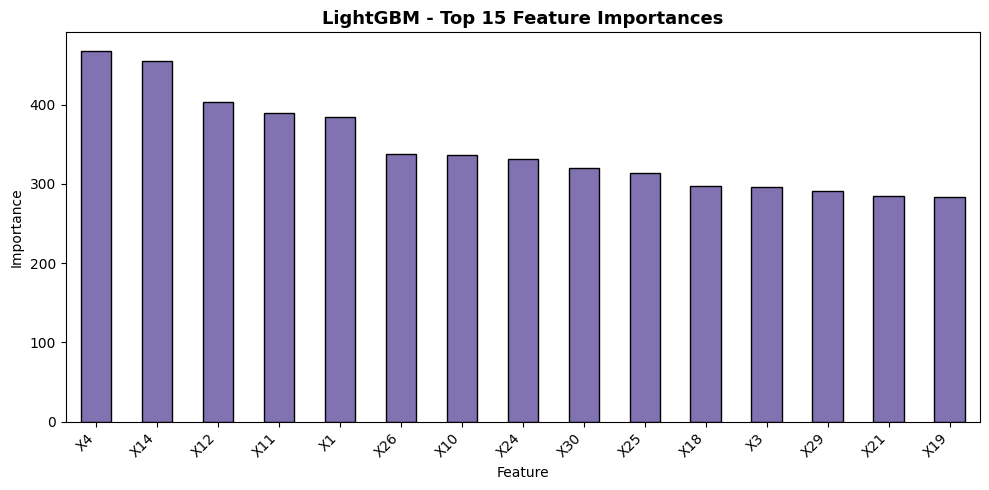

In [40]:
# LightGBM Feature Importance
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
lgbm_importance.head(15).plot(kind='bar', color='#8172B2', edgecolor='black')
plt.title('LightGBM - Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Feature'); plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 - LightGBM Hyperparameter Tuning 

In [41]:
# Sweep the same parameters as XGBoost for consistency and fair comparison
lgbm_tuning_results = []
print(f'{"max_depth":<12} {"lr":<8} {"subsample":<12} {"F1":>8} {"Precision":>10} {"Recall":>8} {"AUC":>8}')
print('-' * 65)

for md in [4, 6, 8]:
    for lr in [0.05, 0.1]:
        for ss in [0.7, 0.8, 0.9]:
            m = LGBMClassifier(
                n_estimators=300,
                max_depth=md,
                learning_rate=lr,
                subsample=ss,
                is_unbalance=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1
            )
            m.fit(X_train_resampled, y_train_resampled)
            prob = m.predict_proba(X_val_scaled)[:, 1]
            ths  = np.arange(0.01, 0.99, 0.01)
            f1s  = [f1_score(y_val, (prob>=t).astype(int), zero_division=0) for t in ths]
            bt   = ths[np.argmax(f1s)]
            pred = (prob >= bt).astype(int)
            f1   = f1_score(y_val, pred, zero_division=0)
            prec = precision_score(y_val, pred, zero_division=0)
            rec  = recall_score(y_val, pred, zero_division=0)
            auc  = roc_auc_score(y_val, prob)
            lgbm_tuning_results.append((md, lr, ss, bt, f1, prec, rec, auc, m))
            print(f'{md:<12} {lr:<8} {ss:<12} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f} {auc:>8.4f}')

# Select best LightGBM combination by F1
lgbm_tuning_results.sort(key=lambda x: -x[4])
best_lgbm_md, best_lgbm_lr, best_lgbm_ss, _, _, _, _, _, lgbm_tuned_model = lgbm_tuning_results[0]
print(f'\nBest parameters: max_depth={best_lgbm_md}, learning_rate={best_lgbm_lr}, subsample={best_lgbm_ss}')

max_depth    lr       subsample          F1  Precision   Recall      AUC
-----------------------------------------------------------------
4            0.05     0.7            0.9091     0.9286   0.8904   0.9892
4            0.05     0.8            0.9091     0.9286   0.8904   0.9892
4            0.05     0.9            0.9091     0.9286   0.8904   0.9892
4            0.1      0.7            0.9306     0.9437   0.9178   0.9889
4            0.1      0.8            0.9306     0.9437   0.9178   0.9889
4            0.1      0.9            0.9306     0.9437   0.9178   0.9889
6            0.05     0.7            0.9091     0.9286   0.8904   0.9905
6            0.05     0.8            0.9091     0.9286   0.8904   0.9905
6            0.05     0.9            0.9091     0.9286   0.8904   0.9905
6            0.1      0.7            0.9028     0.9155   0.8904   0.9884
6            0.1      0.8            0.9028     0.9155   0.8904   0.9884
6            0.1      0.9            0.9028     0.9155   0

In [42]:
# Evaluating tuned LightGBM
lgbm_tuned_results = optimize_threshold_and_evaluate(
    lgbm_tuned_model, X_val_scaled, y_val, 'LightGBM (Tuned)'
)
print('\nClassification Report:')
print(classification_report(y_val, lgbm_tuned_results['pred'],
      target_names=['Do Not Buy (0)', 'Buy (1)'], digits=4))


LightGBM (Tuned) - Optimal Threshold: 0.93
  AUC=0.9889  Acc=0.9997  Sens=0.9178  Spec=0.9999  Prec=0.9437  F1=0.9306

Classification Report:
                precision    recall  f1-score   support

Do Not Buy (0)     0.9998    0.9999    0.9999     36727
       Buy (1)     0.9437    0.9178    0.9306        73

      accuracy                         0.9997     36800
     macro avg     0.9717    0.9588    0.9652     36800
  weighted avg     0.9997    0.9997    0.9997     36800



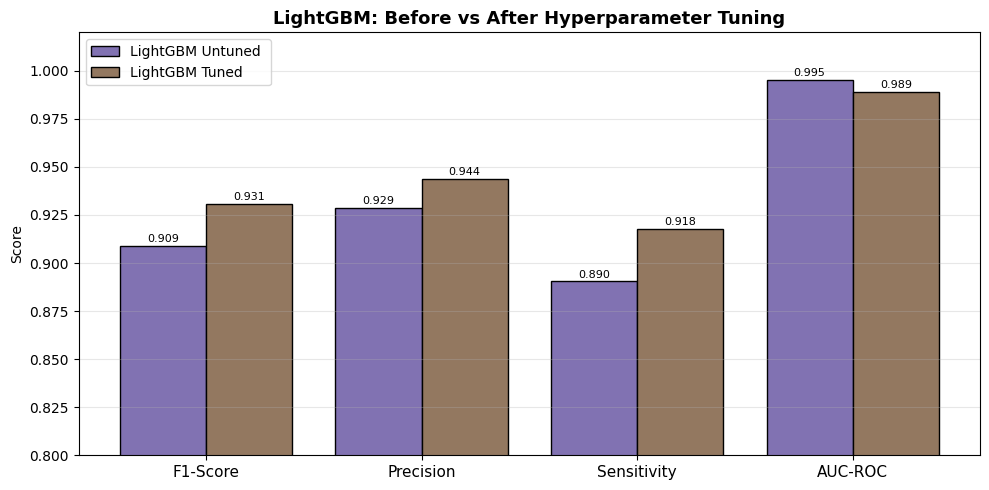

In [43]:
# Comparing tuning improvement as untuned vs tuned LightGBM
metrics = ['F1-Score', 'Precision', 'Sensitivity', 'AUC-ROC']
untuned_vals = [lgbm_results['F1-Score'], lgbm_results['Precision'],
                lgbm_results['Sensitivity'], lgbm_results['AUC-ROC']]
tuned_vals   = [lgbm_tuned_results['F1-Score'], lgbm_tuned_results['Precision'],
                lgbm_tuned_results['Sensitivity'], lgbm_tuned_results['AUC-ROC']]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, untuned_vals, 0.4, label='LightGBM Untuned ', color='#8172B2', edgecolor='black')
ax.bar(x + 0.2, tuned_vals,   0.4, label='LightGBM Tuned ',   color='#937860', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.8, 1.02); ax.set_ylabel('Score'); ax.legend(fontsize=10)
ax.set_title('LightGBM: Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (u, t) in enumerate(zip(untuned_vals, tuned_vals)):
    ax.text(i - 0.2, u + 0.002, f'{u:.3f}', ha='center', fontsize=8)
    ax.text(i + 0.2, t + 0.002, f'{t:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('lgbm_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 13: Full Model Comparison - All Deliverables
### 13.1 ROC Curves - All Models

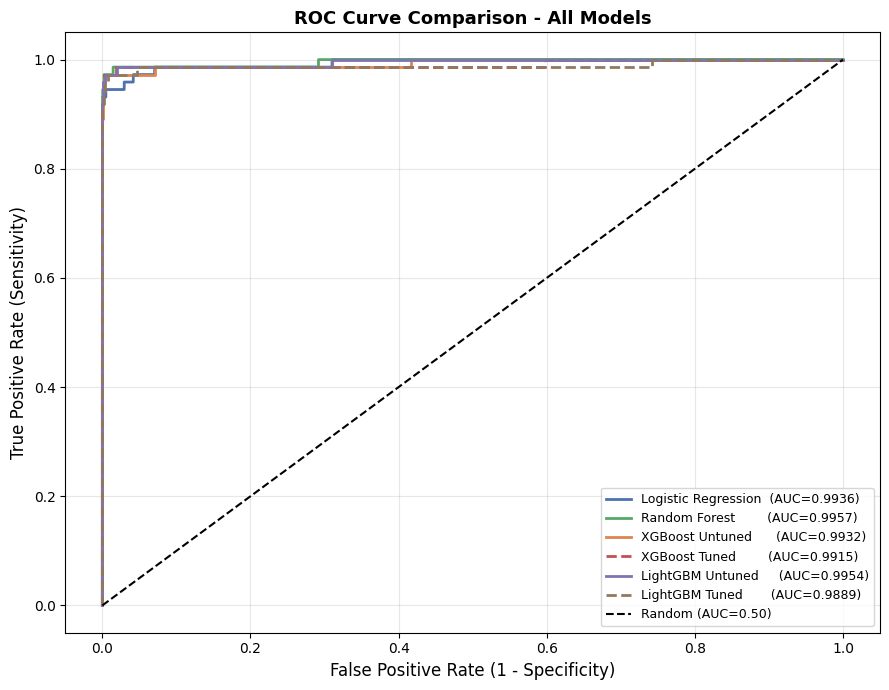

In [44]:
# Computing ROC curves for all models
lr_fpr,       lr_tpr,       _ = roc_curve(y_val, lr_results['prob'])
rf_fpr,       rf_tpr,       _ = roc_curve(y_val, rf_results['prob'])
xgb_fpr,      xgb_tpr,      _ = roc_curve(y_val, xgb_results['prob'])
xgb_t_fpr,    xgb_t_tpr,    _ = roc_curve(y_val, xgb_tuned_results['prob'])
lgbm_fpr,     lgbm_tpr,     _ = roc_curve(y_val, lgbm_results['prob'])
lgbm_t_fpr,   lgbm_t_tpr,   _ = roc_curve(y_val, lgbm_tuned_results['prob'])

plt.figure(figsize=(9, 7))
plt.plot(lr_fpr,      lr_tpr,      lw=2, label=f'Logistic Regression  (AUC={lr_results["AUC-ROC"]:.4f})',        color='#4C72B0')
plt.plot(rf_fpr,      rf_tpr,      lw=2, label=f'Random Forest        (AUC={rf_results["AUC-ROC"]:.4f})',        color='#55A868')
plt.plot(xgb_fpr,     xgb_tpr,     lw=2, label=f'XGBoost Untuned      (AUC={xgb_results["AUC-ROC"]:.4f})',       color='#DD8452')
plt.plot(xgb_t_fpr,   xgb_t_tpr,   lw=2, label=f'XGBoost Tuned        (AUC={xgb_tuned_results["AUC-ROC"]:.4f})', color='#C44E52', linestyle='--')
plt.plot(lgbm_fpr,    lgbm_tpr,    lw=2, label=f'LightGBM Untuned     (AUC={lgbm_results["AUC-ROC"]:.4f})',      color='#8172B2')
plt.plot(lgbm_t_fpr,  lgbm_t_tpr,  lw=2, label=f'LightGBM Tuned       (AUC={lgbm_tuned_results["AUC-ROC"]:.4f})', color='#937860', linestyle='--')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


### 13.2 Confusion Matrices - All Models

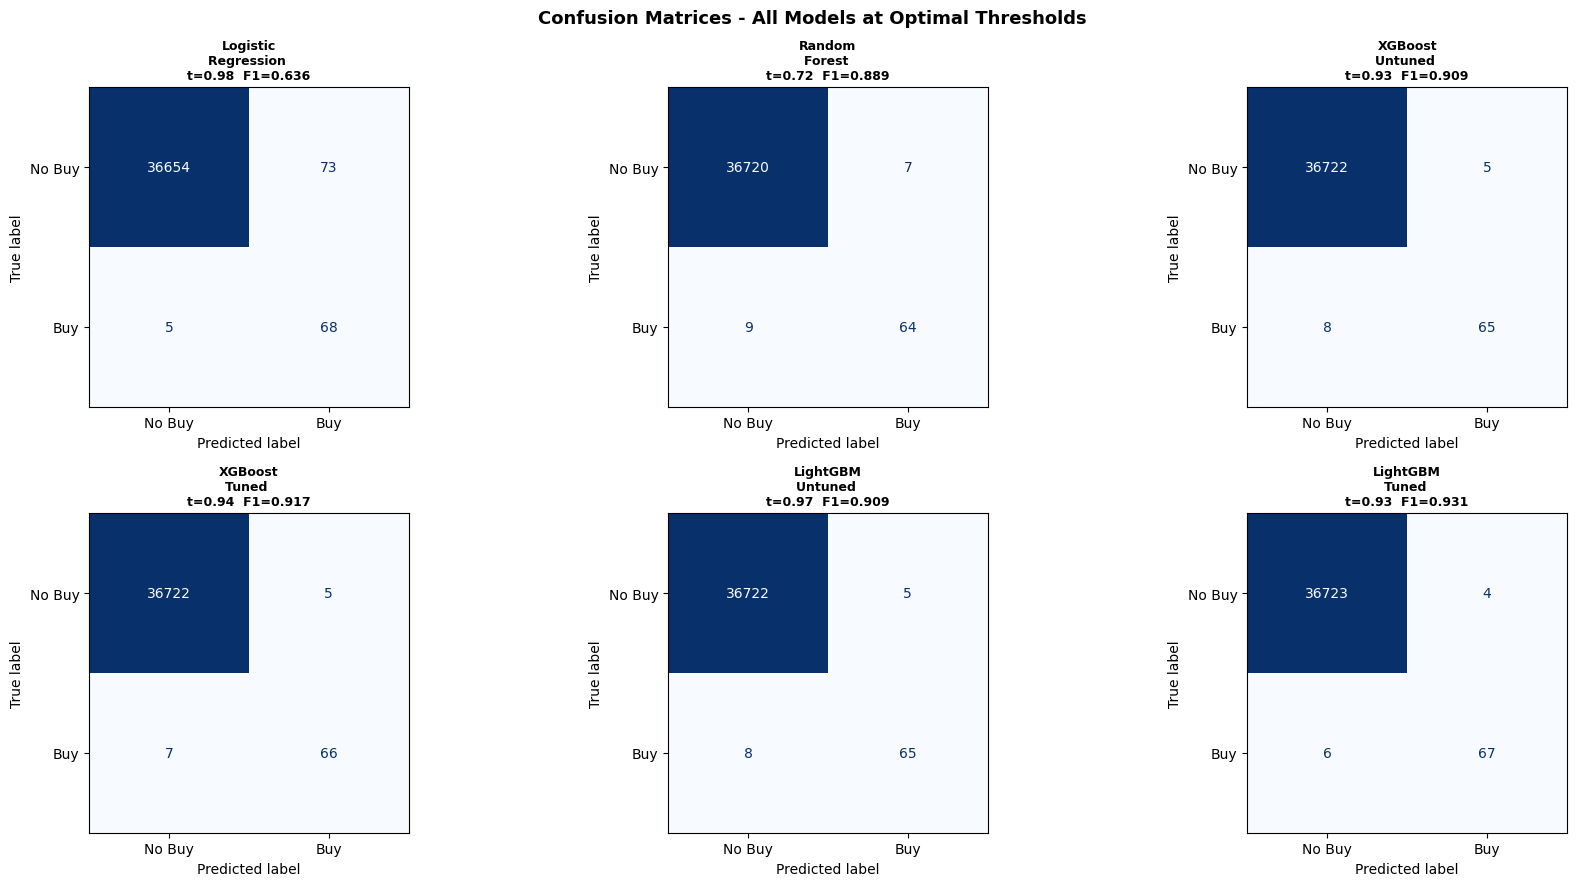

In [45]:
# Side-by-side confusion matrices for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

all_models_info = [
    ('Logistic\nRegression ', lr_results,        '#4C72B0'),
    ('Random\nForest ',       rf_results,        '#55A868'),
    ('XGBoost\nUntuned ',     xgb_results,       '#DD8452'),
    ('XGBoost\nTuned ',       xgb_tuned_results, '#C44E52'),
    ('LightGBM\nUntuned ',    lgbm_results,      '#8172B2'),
    ('LightGBM\nTuned ',      lgbm_tuned_results,'#937860'),
]

for ax, (name, res, color) in zip(axes, all_models_info):
    cm = confusion_matrix(y_val, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Buy', 'Buy']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f'{name}\nt={res["threshold"]:.2f}  F1={res["F1-Score"]:.3f}',
        fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models at Optimal Thresholds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()


### 13.3 Performance Metrics Bar Chart

Full Model Comparison - Validation Set:
                      AUC-ROC  Accuracy  Sensitivity  Specificity  Precision  F1-Score
Logistic Regression    0.9936    0.9979       0.9315       0.9980     0.4823    0.6355
Random Forest          0.9957    0.9996       0.8767       0.9998     0.9014    0.8889
XGBoost Untuned        0.9932    0.9996       0.8904       0.9999     0.9286    0.9091
XGBoost Tuned          0.9915    0.9997       0.9041       0.9999     0.9296    0.9167
LightGBM Untuned       0.9954    0.9996       0.8904       0.9999     0.9286    0.9091
LightGBM Tuned         0.9889    0.9997       0.9178       0.9999     0.9437    0.9306


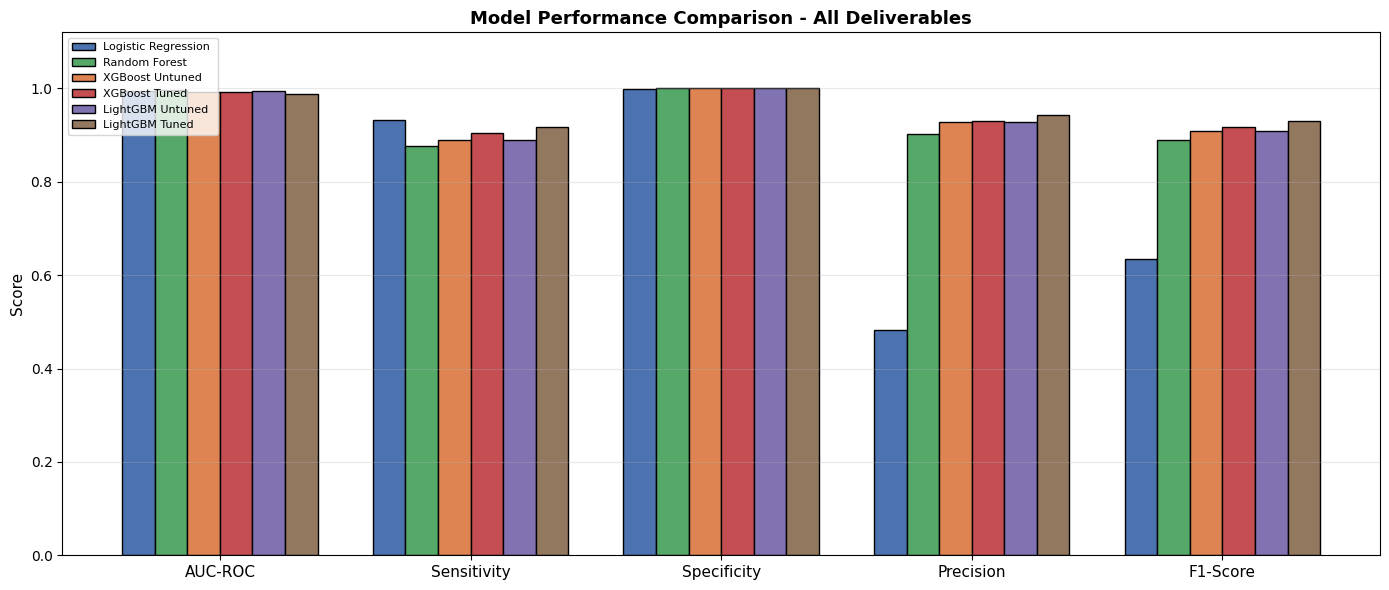

In [46]:
# Building comprehensive comparison table
all_results = {
    'Logistic Regression ': lr_results,
    'Random Forest ':       rf_results,
    'XGBoost Untuned ':     xgb_results,
    'XGBoost Tuned ':       xgb_tuned_results,
    'LightGBM Untuned ':    lgbm_results,
    'LightGBM Tuned ':      lgbm_tuned_results,
}

metrics_cols = ['AUC-ROC', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
comparison_df = pd.DataFrame(
    {name: {m: res[m] for m in metrics_cols} for name, res in all_results.items()}
).T

print('Full Model Comparison - Validation Set:')
print(comparison_df.round(4).to_string())

# Bar chart
metrics_to_plot = ['AUC-ROC', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
x      = np.arange(len(metrics_to_plot))
width  = 0.13
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2', '#937860']

fig, ax = plt.subplots(figsize=(14, 6))
center_offset = (len(all_results) - 1) / 2
for i, (name, res) in enumerate(all_results.items()):
    vals = [res[m] for m in metrics_to_plot]
    ax.bar(x + (i - center_offset) * width, vals, width, label=name, color=colors[i], edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison - All Deliverables', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 14: Best Model Selection & Test Predictions
### 14.1 Select Best Model by F1-Score

In [47]:
# Selecting the best model based on F1-Score
# F1-Score is preferred over AUC-ROC for severe class imbalance (502:1) as it directly balances precision and recall for the minority class
f1_scores_all = {name: res['F1-Score'] for name, res in all_results.items()}
best_model_name = max(f1_scores_all, key=f1_scores_all.get)

print('F1-Scores across all models:')
for name, score in sorted(f1_scores_all.items(), key=lambda x: -x[1]):
    marker = ' <- BEST' if name == best_model_name else ''
    print(f'  {name:<35} {score:.4f}{marker}')

# Map best model name to its object and threshold
model_object_map = {
    'Logistic Regression ': (lr_model,         lr_results['threshold']),
    'Random Forest ':       (rf_model,         rf_results['threshold']),
    'XGBoost Untuned ':     (xgb_model,        xgb_results['threshold']),
    'XGBoost Tuned ':       (xgb_tuned_model,  xgb_tuned_results['threshold']),
    'LightGBM Untuned ':    (lgbm_model,       lgbm_results['threshold']),
    'LightGBM Tuned ':      (lgbm_tuned_model, lgbm_tuned_results['threshold']),
}
best_model_obj, best_threshold = model_object_map[best_model_name]
print(f'\nBest model : {best_model_name}')
print(f'Threshold  : {best_threshold:.2f}')


F1-Scores across all models:
  LightGBM Tuned                      0.9306 <- BEST
  XGBoost Tuned                       0.9167
  XGBoost Untuned                     0.9091
  LightGBM Untuned                    0.9091
  Random Forest                       0.8889
  Logistic Regression                 0.6355

Best model : LightGBM Tuned 
Threshold  : 0.93


### 14.2 Predictions on Original Test Set

In [48]:
# Generating predictions on the original test set using the best model
y_test_old_prob = best_model_obj.predict_proba(X_test_old_scaled)[:, 1]
y_test_old_pred = (y_test_old_prob >= best_threshold).astype(int)

print(f'Original Test Set Predictions ({best_model_name})')
print(f'Threshold: {best_threshold:.2f}')
unique, counts = np.unique(y_test_old_pred, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Buy (1)' if cls == 1 else 'Do Not Buy (0)'
    print(f'  {label}: {cnt:,} ({cnt/len(y_test_old_pred)*100:.2f}%)')

# Saving original test predictions
pd.DataFrame({'y_hat': y_test_old_pred}).to_csv('stock_market_predictions_pd2.csv', index=False)
print('\nSaved: stock_market_predictions_pd2.csv')

Original Test Set Predictions (LightGBM Tuned )
Threshold: 0.93
  Do Not Buy (0): 45,926 (99.84%)
  Buy (1): 74 (0.16%)

Saved: stock_market_predictions_pd2.csv


### 14.3 Predictions on New Test Set

In [49]:
# Generating predictions on the new test set using the best model
y_test_new_prob = best_model_obj.predict_proba(X_test_new_scaled)[:, 1]
y_test_new_pred = (y_test_new_prob >= best_threshold).astype(int)

print(f'New Test Set Predictions ({best_model_name})')
print(f'Threshold: {best_threshold:.2f}')
unique, counts = np.unique(y_test_new_pred, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'Buy (1)' if cls == 1 else 'Do Not Buy (0)'
    print(f'  {label}: {cnt:,} ({cnt/len(y_test_new_pred)*100:.2f}%)')

# Saving new test predictions
pd.DataFrame({'y_hat': y_test_new_pred}).to_csv('stock_market_predictions_pd3.csv', index=False)
print('\nSaved: stock_market_predictions_pd3.csv')

New Test Set Predictions (LightGBM Tuned )
Threshold: 0.93
  Do Not Buy (0): 42,425 (92.23%)
  Buy (1): 3,575 (7.77%)

Saved: stock_market_predictions_pd3.csv


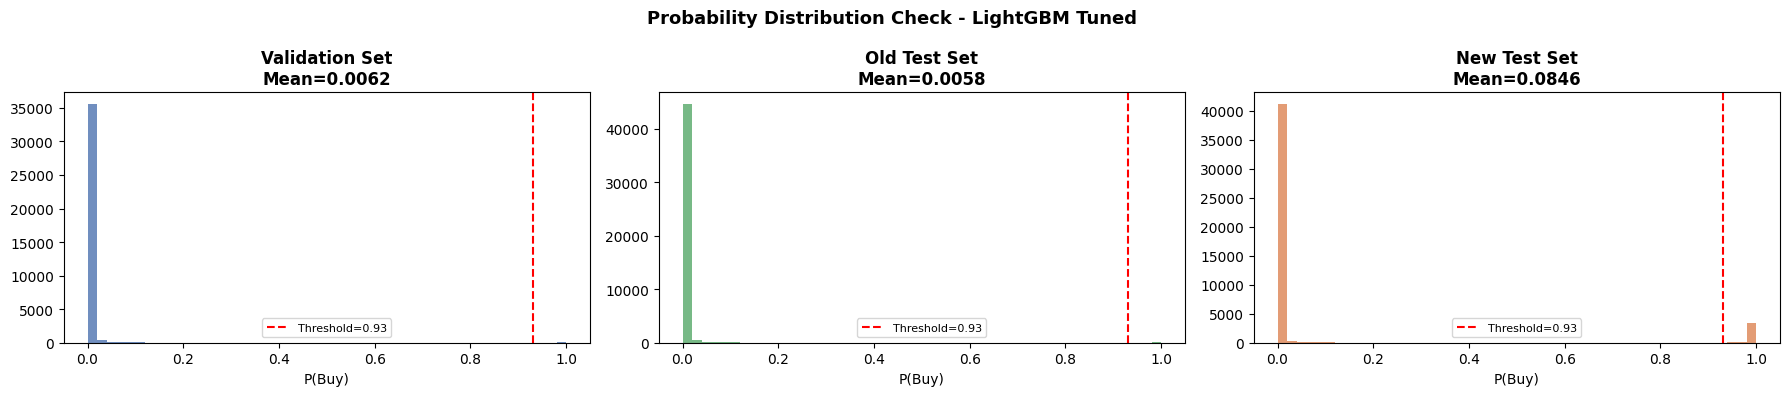

Val mean prob      : 0.0062
Old test mean prob : 0.0058
New test mean prob : 0.0846


In [50]:
# Comparing probability distributions: Validation vs Old Test vs New Test
best_val_prob = all_results[best_model_name]['prob']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
datasets = [
    ('Validation Set', best_val_prob,    '#4C72B0'),
    ('Old Test Set',   y_test_old_prob,  '#55A868'),
    ('New Test Set',   y_test_new_prob,  '#DD8452'),
]
for ax, (title, probs, color) in zip(axes, datasets):
    ax.hist(probs, bins=50, color=color, edgecolor='none', alpha=0.8)
    ax.axvline(best_threshold, color='red', linestyle='--',
               label=f'Threshold={best_threshold:.2f}')
    ax.set_title(f'{title}\nMean={probs.mean():.4f}', fontweight='bold')
    ax.set_xlabel('P(Buy)'); ax.legend(fontsize=8)

plt.suptitle(f'Probability Distribution Check - {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prob_distribution_check.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Val mean prob      : {best_val_prob.mean():.4f}')
print(f'Old test mean prob : {y_test_old_prob.mean():.4f}')
print(f'New test mean prob : {y_test_new_prob.mean():.4f}')

---
## Step 14: Final Summary - All Models & Deliverables

In [51]:
print('=' * 72)
print('        FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 72)
print(f'{"Model":<35} {"AUC":>6} {"Acc":>6} {"Sens":>6} {"Spec":>6} {"Prec":>6} {"F1":>6}')
print('-' * 72)
for name, res in all_results.items():
    marker = ' <- BEST' if name == best_model_name else ''
    print(f'{name:<35} {res["AUC-ROC"]:>6.4f} {res["Accuracy"]:>6.4f} '
          f'{res["Sensitivity"]:>6.4f} {res["Specificity"]:>6.4f} '
          f'{res["Precision"]:>6.4f} {res["F1-Score"]:>6.4f}{marker}')
print('=' * 72)
print(f'Selection criterion : F1-Score (optimal for 502:1 class imbalance)')
print(f'Best model          : {best_model_name}')
print(f'Old test CSV        : stock_market_predictions_pd2.csv')
print(f'New test CSV        : stock_market_predictions_pd3.csv')
print('=' * 72)

        FINAL MODEL PERFORMANCE SUMMARY
Model                                  AUC    Acc   Sens   Spec   Prec     F1
------------------------------------------------------------------------
Logistic Regression                 0.9936 0.9979 0.9315 0.9980 0.4823 0.6355
Random Forest                       0.9957 0.9996 0.8767 0.9998 0.9014 0.8889
XGBoost Untuned                     0.9932 0.9996 0.8904 0.9999 0.9286 0.9091
XGBoost Tuned                       0.9915 0.9997 0.9041 0.9999 0.9296 0.9167
LightGBM Untuned                    0.9954 0.9996 0.8904 0.9999 0.9286 0.9091
LightGBM Tuned                      0.9889 0.9997 0.9178 0.9999 0.9437 0.9306 <- BEST
Selection criterion : F1-Score (optimal for 502:1 class imbalance)
Best model          : LightGBM Tuned 
Old test CSV        : stock_market_predictions_pd2.csv
New test CSV        : stock_market_predictions_pd3.csv
